# Анализ датасета RFSD (на ограниченной выборке)

## Цель работы

Выполнить анализ датасета RFSD на ограниченной выборке:

- 20 колонок;
- 1000 строк.

В ходе работы необходимо:
1. получить описательную статистику для датасета;
2. построить гистограммы для 3 информативных признаков;
3. вычислить и визуализировать матрицу корреляции между всеми 20 колонками;
4. построить диаграммы рассеивания между коррелирующими колонками;
5. сделать выводы исходя из описательной статистики, гистограмм, матрицы корреляции, диаграммы рассеивания.

## Особенности датасета

Большой датасет RFSD выложен и хранится на **Hugging Face** (https://huggingface.co/datasets/irlspbru/RFSD).  
Датасет, разбитый на набор .arrow-файлов, скачивается локально.  
Данные считываются выборочно, без загрузки всего датасета в память.

## Именование финансовых признаков

Финансовые признаки в датасете имеют имена вида `line_XXXX`.  
Для повышения читаемости они переименованы с использованием словаря RFSD 'aux_data/descriptive_names_dict.csv'.    

  

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

sns.set(style="whitegrid", context="notebook")

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

# требуется подстановка соответствующего пути к датасету в виде набора .arrow файлов 
DATA_DIR = r"C:\Users\edwan\.cache\huggingface\datasets\irlspbru___rfsd\default\0.0.0\c7084c96e94ddba86d1156e627f9a383b60c4eb1"

files = sorted(glob.glob(os.path.join(DATA_DIR, "*.arrow")))
print(f"Найдено {len(files)} arrow-файлов.")
assert len(files) > 0, "Arrow-файлы не найдены"


Найдено 211 arrow-файлов.


## Выбор признаков

По условию задания нужно выбрать 20 признаков (колонок).
### В выборку включены признаки:
- region
- region_taxcode
- age
- eligible
- filed
- imputed
- simplified
- okved
- okved_section
- geocoding_quality
- line_1100
- line_1200
- line_1230
- line_1250
- line_1300
- line_1500
- line_1600
- line_1700
- line_2300
- line_2400  
    

In [2]:
selected_cols = [
    "region",
    "region_taxcode",
    "age",
    "eligible",
    "filed",
    "imputed",
    "simplified",
    "okved",
    "okved_section",
    "geocoding_quality",
    "line_1100",
    "line_1200",
    "line_1230",
    "line_1250",
    "line_1300",
    "line_1500",
    "line_1600",
    "line_1700",
    "line_2300",
    "line_2400",
]

print("Количество выбранных колонок:", len(selected_cols))
print(selected_cols)


Количество выбранных колонок: 20
['region', 'region_taxcode', 'age', 'eligible', 'filed', 'imputed', 'simplified', 'okved', 'okved_section', 'geocoding_quality', 'line_1100', 'line_1200', 'line_1230', 'line_1250', 'line_1300', 'line_1500', 'line_1600', 'line_1700', 'line_2300', 'line_2400']


## Формирование рабочей выборки

Чтобы не загружать весь датасет, используются:
- 10 файлов arrow (shards), равномерно распределённых по датасету;
- выборка строк из каждого файла.

Итоговая рабочая выборка должна содержать **1000 строк**.

In [3]:
n_shards_for_sample = 10
shard_idx = np.linspace(0, len(files) - 1, n_shards_for_sample, dtype=int)
sample_files = [files[i] for i in shard_idx]

rows_total = 1000
rows_per_shard = rows_total // len(sample_files)

dfs = []

for f in sample_files:
    ds = Dataset.from_file(f)

    cols_in_file = [c for c in selected_cols if c in ds.column_names]
    ds_small = ds.remove_columns([c for c in ds.column_names if c not in cols_in_file])

    n = min(rows_per_shard, ds_small.num_rows)
    idx = rng.choice(ds_small.num_rows, size=n, replace=False)
    idx = sorted(idx.tolist())

    part = ds_small.select(idx).to_pandas()
    dfs.append(part)

    print(f"{os.path.basename(f)} -> {n} строк")

df = pd.concat(dfs, ignore_index=True)

if len(df) > 1000:
    df = df.sample(1000, random_state=RANDOM_STATE).reset_index(drop=True)
elif len(df) < 1000:
    print(f"Внимание: получено только {len(df)} строк!")

print("\nРазмер итоговой выборки:", df.shape)
display(df.head(10))


rfsd-train-00000-of-00211.arrow -> 100 строк
rfsd-train-00023-of-00211.arrow -> 100 строк
rfsd-train-00046-of-00211.arrow -> 100 строк
rfsd-train-00070-of-00211.arrow -> 100 строк
rfsd-train-00093-of-00211.arrow -> 100 строк
rfsd-train-00116-of-00211.arrow -> 100 строк
rfsd-train-00140-of-00211.arrow -> 100 строк
rfsd-train-00163-of-00211.arrow -> 100 строк
rfsd-train-00186-of-00211.arrow -> 100 строк
rfsd-train-00210-of-00211.arrow -> 100 строк

Размер итоговой выборки: (1000, 20)


,region,region_taxcode,age,eligible,filed,imputed,simplified,okved,okved_section,geocoding_quality,line_1100,line_1200,line_1230,line_1250,line_1300,line_1500,line_1600,line_1700,line_2300,line_2400
0,bashkortostan,0200,11.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,tatarstan,1600,8.0,1.0,0.0,0.0,NaN,43.21,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,bashkortostan,0200,3.0,1.0,0.0,0.0,NaN,02.10,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,bashkortostan,0200,5.0,1.0,0.0,0.0,NaN,68.31.50,L,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,bashkortostan,0200,2.0,1.0,0.0,0.0,NaN,41.20,F,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,bashkortostan,0200,5.0,1.0,0.0,1.0,1.0,47.78.10,G,NaN,111.0,8839.0,3381.0,792.0,-813.0,9763.0,8950.0,8950.0,120.0,96.0
6,bashkortostan,0200,20.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,bashkortostan,0200,8.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,bashkortostan,0200,1.0,1.0,0.0,0.0,NaN,46.43.10,G,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,bashkortostan,0200,10.0,1.0,0.0,0.0,NaN,01.41,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Переименование финансовых признаков

Числовые названия финансовых признаков, колонки вида line_* переименовываются с использованием словаря RFSD.  


In [4]:
rename_url = "https://raw.githubusercontent.com/irlcode/RFSD/main/aux_data/descriptive_names_dict.csv"
renaming_df = pd.read_csv(rename_url)

print("Первые строки словаря переименований:")
display(renaming_df.head())

rename_dict = dict(zip(renaming_df["original"], renaming_df["descriptive"]))

financial_cols_original = [c for c in selected_cols if c.startswith("line_")]
rename_dict_filtered = {k: rename_dict[k] for k in financial_cols_original if k in rename_dict}

print("Переименование финансовых колонок:")
for old, new in rename_dict_filtered.items():
    print(f"{old} -> {new}")

df = df.rename(columns=rename_dict_filtered)

selected_cols_renamed = [rename_dict.get(col, col) for col in selected_cols]

print("\nКолонки после переименования:")
print(selected_cols_renamed)


Первые строки словаря переименований:


,original,descriptive
0,year,year
1,inn,inn
2,ogrn,ogrn
3,region,region
4,region_taxcode,region_taxcode


Переименование финансовых колонок:
line_1100 -> B_noncurrent_assets
line_1200 -> B_current_assets
line_1230 -> B_accounts_receivable
line_1250 -> B_cash_equivalents
line_1300 -> B_total_equity
line_1500 -> B_shortterm_liab
line_1600 -> B_assets
line_1700 -> B_liab
line_2300 -> PL_before_tax
line_2400 -> PL_net_profit

Колонки после переименования:
['region', 'region_taxcode', 'age', 'eligible', 'filed', 'imputed', 'simplified', 'okved', 'okved_section', 'geocoding_quality', 'B_noncurrent_assets', 'B_current_assets', 'B_accounts_receivable', 'B_cash_equivalents', 'B_total_equity', 'B_shortterm_liab', 'B_assets', 'B_liab', 'PL_before_tax', 'PL_net_profit']


### Сопоставление кодов и названий строк отчетности дает следующий результат:

### Коды Бухгалтерского баланса (Форма № 1)
1100 — Итого внеоборотных активов — B_noncurrent_assets  
1200 — Итого оборотных активов — B_current_assets  
1230 — Дебиторская задолженность — B_accounts_receivable  
1250 — Денежные средства и денежные эквиваленты — B_cash_equivalents  
1300 — Итого по разделу «Капитал и резервы» — B_total_equity  
1500 — Итого краткосрочных обязательств — B_shortterm_liab  
1600 — Баланс (сумма актива) — B_assets  
1700 — Баланс (сумма пассива) — B_liab  

### Коды Отчета о финансовых результатах (Форма № 2)
2300 — Прибыль (убыток) до налогообложения — PL_before_tax  
2400 — Чистая прибыль (убыток) — PL_net_profit  

In [5]:
mapping_table = pd.DataFrame({
    "original_name": selected_cols,
    "renamed_name": [rename_dict.get(col, col) for col in selected_cols]
})

display(mapping_table)


,original_name,renamed_name
0,region,region
1,region_taxcode,region_taxcode
2,age,age
3,eligible,eligible
4,filed,filed
5,imputed,imputed
6,simplified,simplified
7,okved,okved
8,okved_section,okved_section
9,geocoding_quality,geocoding_quality


## Справочник признаков

Ниже формируется словарь подписей, который будет использоваться в таблицах и графиках.  
Для финансовых признаков в подписи сохраняются:
- новое читаемое имя;
- исходное имя `line_XXXX`.
  

In [6]:
feature_labels = {
    "region": "Регион",
    "region_taxcode": "Код региона",
    "age": "Возраст компании",
    "eligible": "Флаг eligible",
    "filed": "Подана отчетность (filed)",
    "imputed": "Импутированные данные (imputed)",
    "simplified": "Упрощенная отчетность (simplified)",
    "okved": "Код ОКВЭД",
    "okved_section": "Секция ОКВЭД",
    "geocoding_quality": "Качество геокодирования",
}

for old_name, new_name in rename_dict_filtered.items():
    feature_labels[new_name] = f"{new_name} ({old_name})"

print("Примеры подписей:")
for col in selected_cols_renamed:
    print(f"{col} -> {feature_labels.get(col, col)}")
    

Примеры подписей:
region -> Регион
region_taxcode -> Код региона
age -> Возраст компании
eligible -> Флаг eligible
filed -> Подана отчетность (filed)
imputed -> Импутированные данные (imputed)
simplified -> Упрощенная отчетность (simplified)
okved -> Код ОКВЭД
okved_section -> Секция ОКВЭД
geocoding_quality -> Качество геокодирования
B_noncurrent_assets -> B_noncurrent_assets (line_1100)
B_current_assets -> B_current_assets (line_1200)
B_accounts_receivable -> B_accounts_receivable (line_1230)
B_cash_equivalents -> B_cash_equivalents (line_1250)
B_total_equity -> B_total_equity (line_1300)
B_shortterm_liab -> B_shortterm_liab (line_1500)
B_assets -> B_assets (line_1600)
B_liab -> B_liab (line_1700)
PL_before_tax -> PL_before_tax (line_2300)
PL_net_profit -> PL_net_profit (line_2400)


## Анализ пропусков

Перед основным анализом оценим долю пропусков по выбранным признакам.  


In [7]:
missing_pct = (df[selected_cols_renamed].isna().mean() * 100).round(2).sort_values(ascending=False)
display(missing_pct.to_frame("missing_pct"))


,missing_pct
B_noncurrent_assets,81.6
PL_before_tax,64.0
PL_net_profit,63.5
B_accounts_receivable,63.4
B_shortterm_liab,62.5
B_cash_equivalents,61.9
B_total_equity,57.2
B_current_assets,56.7
B_assets,55.5
B_liab,55.4


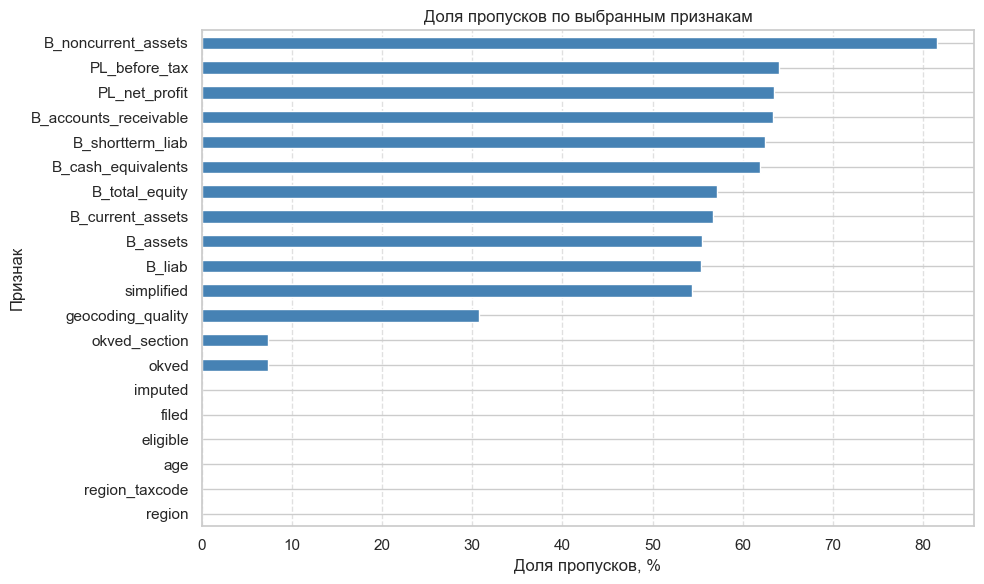


Вывод:
Наибольшая доля пропусков наблюдается у финансовых признаков.
Вероятно, не все компании подают одинаково полную отчетность.
Пропуски здесь отражают отсутствие отчетности или неприменимость признака.


In [8]:
plt.figure(figsize=(10, 6))
missing_pct.sort_values().plot(kind="barh", color="steelblue")
plt.title("Доля пропусков по выбранным признакам")
plt.xlabel("Доля пропусков, %")
plt.ylabel("Признак")
plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

print("\nВывод:")
print("Наибольшая доля пропусков наблюдается у финансовых признаков.")
print("Вероятно, не все компании подают одинаково полную отчетность.")
print("Пропуски здесь отражают отсутствие отчетности или неприменимость признака.")


# 1. Описательная статистика

Рассчитаем статистику для:
- числовых признаков;
- категориальных признаков.

In [9]:
numeric_cols = df[selected_cols_renamed].select_dtypes(include=["number"]).columns.tolist()

desc_num = df[numeric_cols].describe().T
desc_num["missing_pct"] = (df[numeric_cols].isna().mean() * 100).round(2)

display(desc_num)


,count,mean,std,min,25%,50%,75%,max,missing_pct
age,1000.0,6.892000,6.058469,0.0,2.00,5.0,10.00,41.0,0.0
eligible,1000.0,0.989000,0.104355,0.0,1.00,1.0,1.00,1.0,0.0
filed,1000.0,0.398000,0.489730,0.0,0.00,0.0,1.00,1.0,0.0
imputed,1000.0,0.049000,0.215976,0.0,0.00,0.0,0.00,1.0,0.0
simplified,456.0,0.550439,0.497996,0.0,0.00,1.0,1.00,1.0,54.4
B_noncurrent_assets,184.0,87671.646739,757779.607430,-46.0,33.75,253.5,2803.25,9963622.0,81.6
B_current_assets,433.0,39973.249423,158566.786128,0.0,224.00,1992.0,9498.00,1599812.0,56.7
B_accounts_receivable,366.0,24657.644809,91404.360541,0.0,190.25,1385.5,7171.25,993243.0,63.4
B_cash_equivalents,381.0,7908.703412,65089.785010,-14758.0,14.00,108.0,712.00,925704.0,61.9
B_total_equity,428.0,35108.355140,475541.768030,-45530.0,10.00,297.5,3078.00,9703435.0,57.2


In [10]:
categorical_cols = df[selected_cols_renamed].select_dtypes(include=["object", "string"]).columns.tolist()

summary_cat = pd.DataFrame({
    "missing_pct": (df[categorical_cols].isna().mean() * 100).round(2),
    "nunique": df[categorical_cols].nunique(dropna=True)
}).sort_values("nunique", ascending=False)

display(summary_cat)

for col in categorical_cols:
    print(f"\nТоп значений для признака: {feature_labels.get(col, col)}")
    display(df[col].value_counts(dropna=False).head(10).to_frame("count"))
    

,missing_pct,nunique
okved,7.3,347
region,0.0,46
region_taxcode,0.0,46
okved_section,7.3,19
geocoding_quality,30.7,3



Топ значений для признака: Регион


,count
region,
moscow city,337
sankt-petersburg,150
moscow reg.,112
tatarstan,49
nizhni novgorod,27
bashkortostan,24
novosibirsk,24
voronezh,22
udmurtia,19



Топ значений для признака: Код региона


,count
region_taxcode,
7700,337
7800,150
5000,112
1600,49
5200,27
0200,24
5400,24
3600,22
1800,19


...

,count
okved,
NaN,73
41.20,55
46.90,54
46.73,23
69.10,18
94.99,17
43.21,15
52.29,15
68.32,14



Топ значений для признака: Секция ОКВЭД


,count
okved_section,
G,311
F,108
M,89
C,81
L,77
NaN,73
H,65
S,41
N,32



Топ значений для признака: Качество геокодирования


,count
geocoding_quality,
house,343
NaN,307
street,304
city,46


In [11]:
print("\nВывод по описательной статистике:")
print("1) В выборке медианный возраст компании составляет 5 лет, средний возраст — около 6.9 года.")
print("2) Признак filed = 1 встречается у 39.8% компаний.")
print("3) Финансовые признаки имеют большие разбросы и выраженные выбросы.")
print("4) Средние значения многих финансовых признаков намного больше медиан, что указывает на сильную асимметрию распределений.")



Вывод по описательной статистике:
1) В выборке медианный возраст компании составляет 5 лет, средний возраст — около 6.9 года.
2) Признак filed = 1 встречается у 39.8% компаний.
3) Финансовые признаки имеют большие разбросы и выраженные выбросы.
4) Средние значения многих финансовых признаков намного больше медиан, что указывает на сильную асимметрию распределений.


### 2. Гистограммы для 3 информативных колонок

Для визуального анализа выбраны 3 информативные колонки:

- 'age' — возраст компании;
- признак, соответствующий строке 'line_1600' — итоговый показатель баланса;
- признак, соответствующий строке 'line_2400' — чистая прибыль (убыток).  


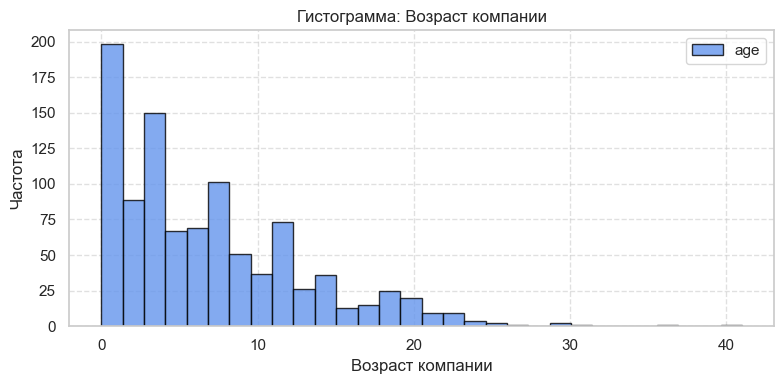

count    1000.000000
mean        6.892000
std         6.058469
min         0.000000
25%         2.000000
50%         5.000000
75%        10.000000
max        41.000000
Name: age, dtype: float64


Вывод:
В данной выборке преобладают сравнительно молодые компании:
медиана возраста равна 5 годам, максимум равен 41 году, и не выглядит некорректным.


In [12]:
col = "age"

plt.figure(figsize=(8, 4))
plt.hist(df[col].dropna(), bins=30, color="cornflowerblue", edgecolor="black", alpha=0.8, label="age")
plt.title(f"Гистограмма: {feature_labels[col]}")
plt.xlabel(feature_labels[col])
plt.ylabel("Частота")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

display(df[col].describe())

print("\nВывод:")
print("В данной выборке преобладают сравнительно молодые компании:")
print("медиана возраста равна 5 годам, максимум равен 41 году, и не выглядит некорректным.")


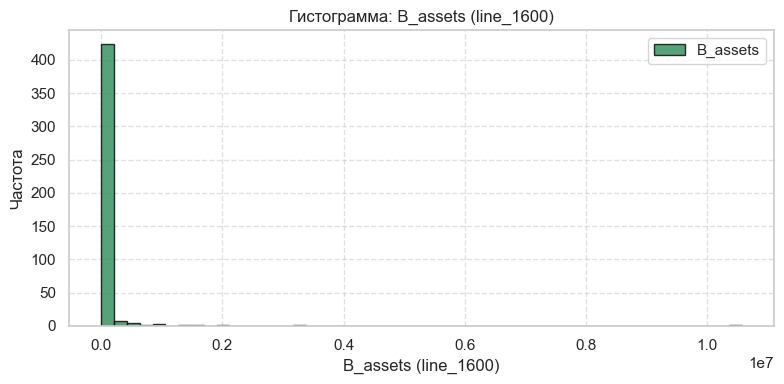

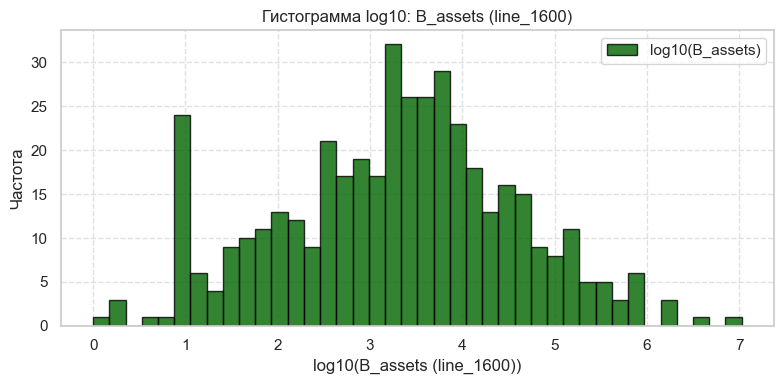

count    4.450000e+02
mean     7.514607e+04
std      5.511727e+05
min      0.000000e+00
25%      1.830000e+02
50%      1.999000e+03
75%      1.140500e+04
max      1.057255e+07
Name: B_assets, dtype: float64


Количество выбросов по правилу IQR для B_assets: 80


,B_assets,region,okved_section,age
24,129840.0,buryatia,A,5.0
82,37023.0,mordovia,F,0.0
109,102382.0,magadan,B,1.0
112,49011.0,moscow city,A,6.0
142,56373.0,moscow reg.,H,13.0
148,131501.0,moscow reg.,C,3.0
150,39547.0,moscow reg.,G,0.0
153,83867.0,moscow reg.,C,4.0
203,55146.0,nizhni novgorod,G,4.0
207,46784.0,yaroslavl,J,9.0



Вывод:
Распределение итогового показателя баланса смещено вправо.
У большинства компаний значения невелики, но присутствует небольшое число очень крупных организаций.
Распределение содержит выбросы и длинный правый хвост.


In [13]:
col = rename_dict.get("line_1600", "line_1600")

plt.figure(figsize=(8, 4))
plt.hist(df[col].dropna(), bins=50, color="seagreen", edgecolor="black", alpha=0.8, label=col)
plt.title(f"Гистограмма: {feature_labels[col]}")
plt.xlabel(feature_labels[col])
plt.ylabel("Частота")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

positive_values = df.loc[df[col] > 0, col]

plt.figure(figsize=(8, 4))
plt.hist(np.log10(positive_values), bins=40, color="darkgreen", edgecolor="black", alpha=0.8, label=f"log10({col})")
plt.title(f"Гистограмма log10: {feature_labels[col]}")
plt.xlabel(f"log10({feature_labels[col]})")
plt.ylabel("Частота")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

display(df[col].describe())

q1 = df[col].quantile(0.25)
q3 = df[col].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
print(f"\nКоличество выбросов по правилу IQR для {col}: {len(outliers)}")
display(outliers[[col, "region", "okved_section", "age"]].head(20))

print("\nВывод:")
print("Распределение итогового показателя баланса смещено вправо.")
print("У большинства компаний значения невелики, но присутствует небольшое число очень крупных организаций.")
print("Распределение содержит выбросы и длинный правый хвост.")


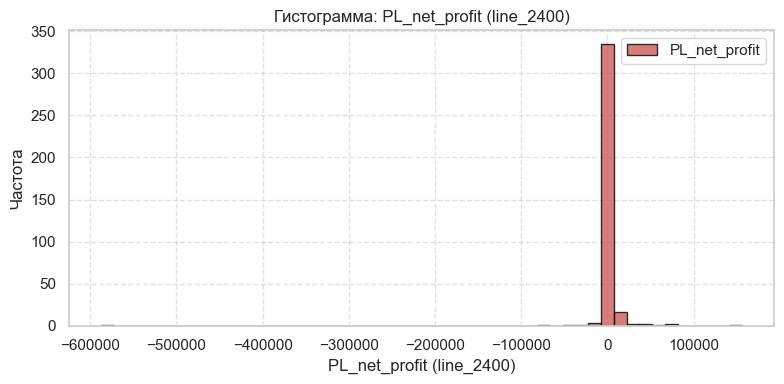

count       365.000000
mean        156.610959
std       33187.230396
min     -587182.000000
25%          -5.000000
50%          79.000000
75%         572.000000
max      155997.000000
Name: PL_net_profit, dtype: float64


Количество выбросов по правилу IQR для PL_net_profit: 95


,PL_net_profit,region,okved_section,age
24,14312.0,buryatia,A,5.0
63,1671.0,komi,M,1.0
77,-10090.0,marij el,L,3.0
109,-39154.0,magadan,B,1.0
148,3699.0,moscow reg.,C,3.0
150,-2536.0,moscow reg.,G,0.0
152,2070.0,moscow reg.,G,8.0
161,-1626.0,moscow reg.,I,15.0
162,-1408.0,moscow reg.,G,12.0
203,1899.0,nizhni novgorod,G,4.0



Вывод:
Признак чистой прибыли (убытка) содержит как положительные, так и отрицательные значения.
Это соответствует наличию в выборке как прибыльных, так и убыточных компаний.
Распределение асимметрично, и содержит крупные по модулю выбросы.


In [14]:
col = rename_dict.get("line_2400", "line_2400")

plt.figure(figsize=(8, 4))
plt.hist(df[col].dropna(), bins=50, color="indianred", edgecolor="black", alpha=0.8, label=col)
plt.title(f"Гистограмма: {feature_labels[col]}")
plt.xlabel(feature_labels[col])
plt.ylabel("Частота")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

display(df[col].describe())

q1 = df[col].quantile(0.25)
q3 = df[col].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
print(f"\nКоличество выбросов по правилу IQR для {col}: {len(outliers)}")
display(outliers[[col, "region", "okved_section", "age"]].head(20))

print("\nВывод:")
print("Признак чистой прибыли (убытка) содержит как положительные, так и отрицательные значения.")
print("Это соответствует наличию в выборке как прибыльных, так и убыточных компаний.")
print("Распределение асимметрично, и содержит крупные по модулю выбросы.")


## Дополнительные закономерности

Чтобы попытаться найти интересные особенности данных, дополнительно рассмотрим:
1. связь между `filed` и наличием финансовых данных;
2. различия возраста компаний по секциям ОКВЭД.  
   

In [15]:
financial_probe_cols = [
    rename_dict.get("line_1100", "line_1100"),
    rename_dict.get("line_1200", "line_1200"),
    rename_dict.get("line_1300", "line_1300"),
    rename_dict.get("line_1600", "line_1600"),
    rename_dict.get("line_2300", "line_2300"),
    rename_dict.get("line_2400", "line_2400"),
]

df["has_financial_data"] = df[financial_probe_cols].notna().any(axis=1).astype(int)

ct = pd.crosstab(df["filed"], df["has_financial_data"], margins=True)
display(ct)


has_financial_data,0,1,All
filed,,,
0.0,553,49,602
1.0,0,398,398
All,553,447,1000


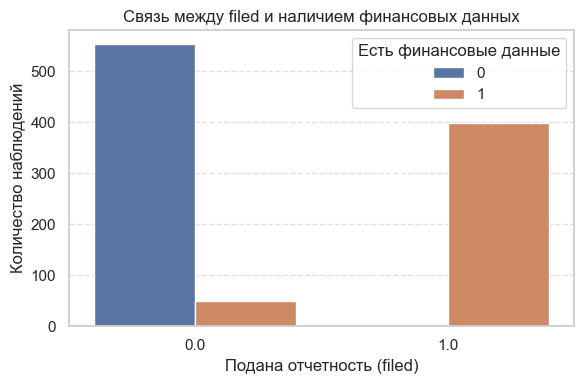


Вывод:
Наличие финансовых данных сильно связано с filed.
Для компаний с filed = 1 финансовые показатели присутствуют почти всегда.
Пропуски в финансовых признаках объясняются отсутствием поданной отчетности.


In [16]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="filed", hue="has_financial_data")
plt.title("Связь между filed и наличием финансовых данных")
plt.xlabel("Подана отчетность (filed)")
plt.ylabel("Количество наблюдений")
plt.legend(title="Есть финансовые данные")
plt.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

print("\nВывод:")
print("Наличие финансовых данных сильно связано с filed.")
print("Для компаний с filed = 1 финансовые показатели присутствуют почти всегда.")
print("Пропуски в финансовых признаках объясняются отсутствием поданной отчетности.")


In [17]:
age_by_okved = (
    df.groupby("okved_section", dropna=False)["age"]
      .agg(["count", "mean", "median"])
      .sort_values("count", ascending=False)
)

display(age_by_okved.head(15))


,count,mean,median
okved_section,,,
G,311,5.147910,4.0
F,108,4.796296,3.0
M,89,6.662921,6.0
C,81,6.456790,4.0
L,77,10.454545,9.0
NaN,73,14.643836,14.0
H,65,6.569231,4.0
S,41,9.268293,8.0
N,32,5.156250,4.0


### Коды ОКВЭД расшифровываются, например, здесь:  
 https://www.regfile.ru/okved2.html  


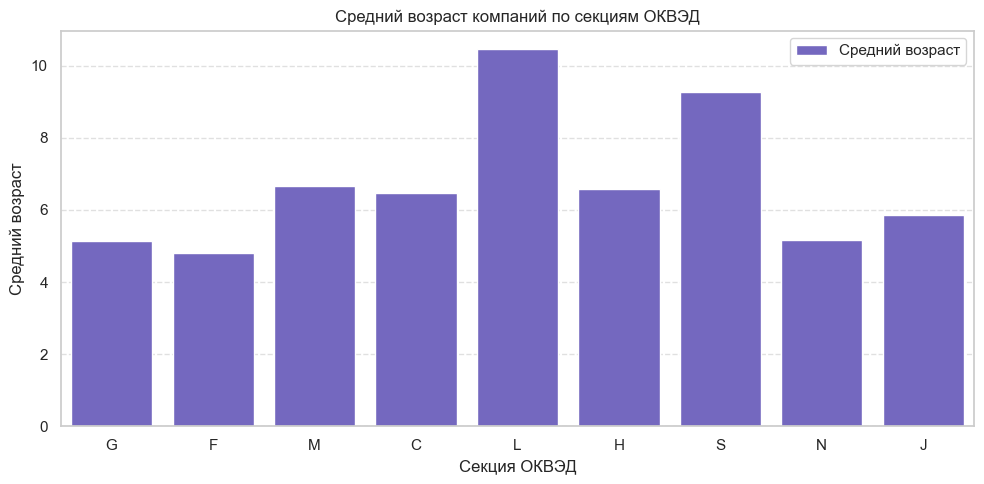


Вывод:
Средний возраст компаний различается между секциями ОКВЭД.
 В секциях строительство (F), торговля (G), административная деятельность (N) больше молодых компаний.
Вывод относится к рассматриваемой выборке из 1000 наблюдений.


In [27]:
plt.figure(figsize=(10, 5))
plot_data = age_by_okved.head(10).reset_index()
sns.barplot(data=plot_data, x="okved_section", y="mean", color="slateblue", label="Средний возраст")
plt.title("Средний возраст компаний по секциям ОКВЭД")
plt.xlabel("Секция ОКВЭД")
plt.ylabel("Средний возраст")
plt.legend()
plt.grid(True, axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

print("\nВывод:")
print("Средний возраст компаний различается между секциями ОКВЭД.")
print(" В секциях строительство (F), торговля (G), административная деятельность (N) больше молодых компаний.")
print("Вывод относится к рассматриваемой выборке из 1000 наблюдений.")

# 3. Матрица корреляции

Для анализа корреляций:
- категориальные признаки временно кодируются числами;
- используется коэффициент Спирмена, так как в данных присутствуют выбросы и несимметричные распределения.

Корреляции категориальных признаков после числового кодирования следует интерпретировать осторожно.


In [19]:
corr_df = df[selected_cols_renamed].copy()
encoded_df = corr_df.copy()

cat_cols = encoded_df.select_dtypes(include=["object", "string"]).columns.tolist()

for col in cat_cols:
    codes = pd.Categorical(encoded_df[col]).codes.astype(float)
    codes[codes == -1] = np.nan
    encoded_df[col] = codes

print("Категориальные столбцы, закодированные для корреляции:")
print(cat_cols)

display(encoded_df.head())


Категориальные столбцы, закодированные для корреляции:
['region', 'region_taxcode', 'okved', 'okved_section', 'geocoding_quality']


,region,region_taxcode,age,eligible,filed,imputed,simplified,okved,okved_section,geocoding_quality,B_noncurrent_assets,B_current_assets,B_accounts_receivable,B_cash_equivalents,B_total_equity,B_shortterm_liab,B_assets,B_liab,PL_before_tax,PL_net_profit
0,3.0,0.0,11.0,1.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,35.0,14.0,8.0,1.0,0.0,0.0,NaN,88.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3.0,0.0,3.0,1.0,0.0,0.0,NaN,9.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3.0,0.0,5.0,1.0,0.0,0.0,NaN,264.0,11.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3.0,0.0,2.0,1.0,0.0,0.0,NaN,82.0,5.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


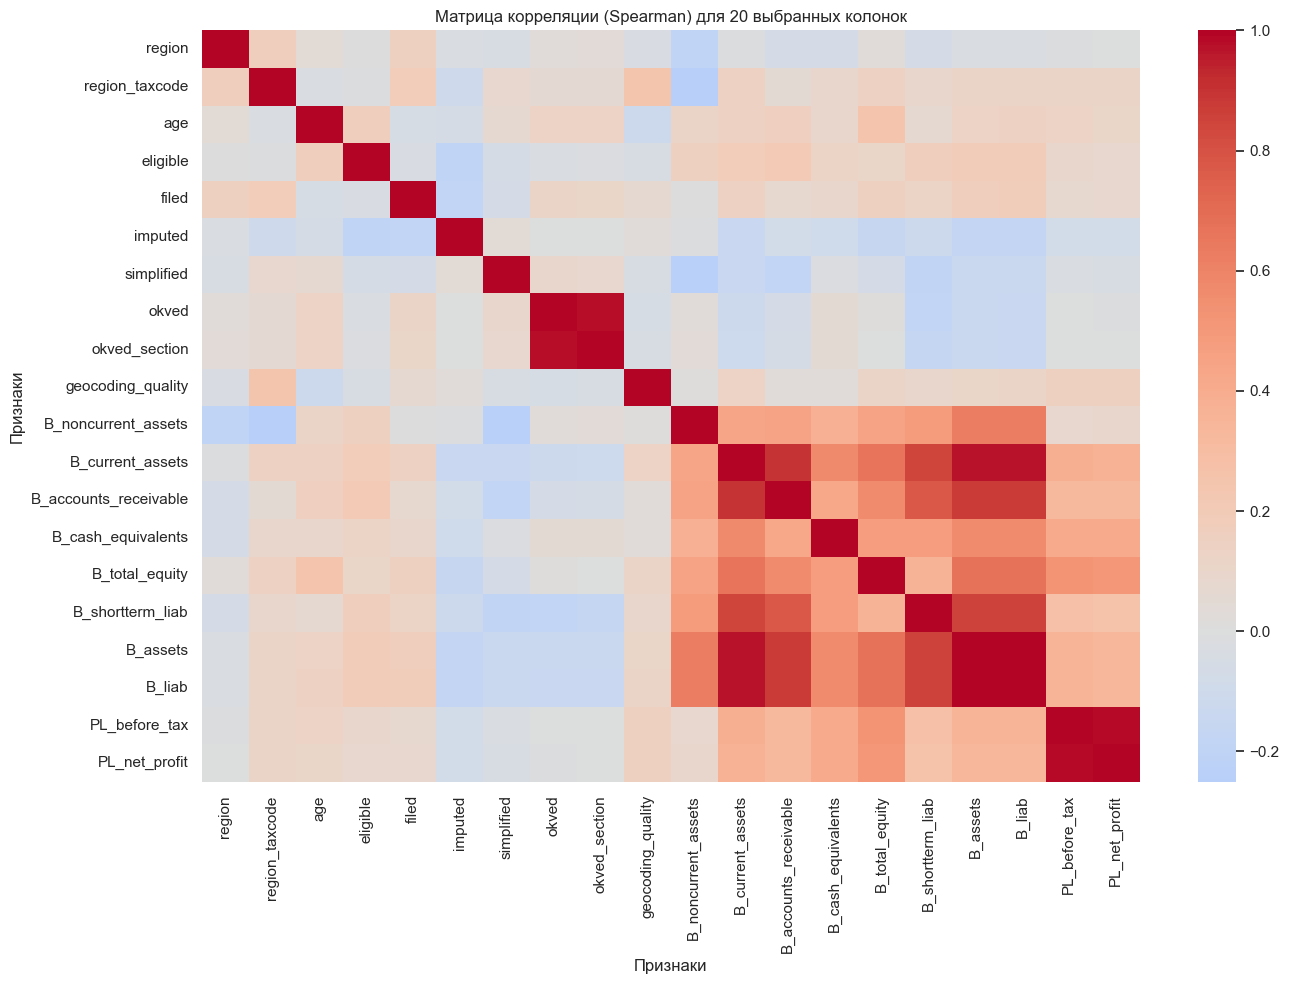

,region,region_taxcode,age,eligible,filed,imputed,simplified,okved,okved_section,geocoding_quality,B_noncurrent_assets,B_current_assets,B_accounts_receivable,B_cash_equivalents,B_total_equity,B_shortterm_liab,B_assets,B_liab,PL_before_tax,PL_net_profit
region,1.000,0.169,0.047,0.005,0.156,-0.029,-0.036,0.030,0.039,-0.036,-0.196,-0.007,-0.067,-0.066,0.028,-0.067,-0.029,-0.028,-0.010,-0.002
region_taxcode,0.169,1.000,-0.025,-0.007,0.181,-0.102,0.081,0.061,0.060,0.243,-0.251,0.146,0.056,0.087,0.140,0.094,0.116,0.119,0.113,0.112
age,0.047,-0.025,1.000,0.165,-0.048,-0.059,0.065,0.131,0.131,-0.118,0.111,0.148,0.160,0.093,0.255,0.069,0.133,0.136,0.126,0.110
eligible,0.005,-0.007,0.165,1.000,-0.032,-0.198,-0.056,-0.026,-0.017,-0.044,0.153,0.183,0.213,0.121,0.103,0.166,0.191,0.189,0.087,0.086
filed,0.156,0.181,-0.048,-0.032,1.000,-0.185,-0.067,0.116,0.108,0.063,0.008,0.140,0.080,0.093,0.156,0.124,0.172,0.175,0.078,0.082
imputed,-0.029,-0.102,-0.059,-0.198,-0.185,1.000,0.043,0.003,-0.000,0.032,-0.008,-0.140,-0.080,-0.093,-0.156,-0.124,-0.172,-0.175,-0.078,-0.082
simplified,-0.036,0.081,0.065,-0.056,-0.067,0.043,1.000,0.089,0.085,-0.037,-0.245,-0.141,-0.182,-0.020,-0.062,-0.191,-0.135,-0.131,-0.030,-0.044
okved,0.030,0.061,0.131,-0.026,0.116,0.003,0.089,1.000,0.979,-0.049,0.031,-0.114,-0.064,0.049,0.014,-0.180,-0.135,-0.141,-0.004,-0.011
okved_section,0.039,0.060,0.131,-0.017,0.108,-0.000,0.085,0.979,1.000,-0.037,0.032,-0.111,-0.054,0.053,0.003,-0.166,-0.133,-0.139,0.000,-0.004
geocoding_quality,-0.036,0.243,-0.118,-0.044,0.063,0.032,-0.037,-0.049,-0.037,1.000,0.016,0.128,0.029,0.026,0.117,0.096,0.110,0.114,0.159,0.155



Комментарий:
Корреляции категориальных признаков после кодирования числами оцениваются условно.
Корреляции числовых финансовых признаков рассматриваются без оговорок.


In [20]:
corr = encoded_df.corr(method="spearman")

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Матрица корреляции (Spearman) для 20 выбранных колонок")
plt.xlabel("Признаки")
plt.ylabel("Признаки")
plt.tight_layout()
plt.show()

display(corr.round(3))

print("\nКомментарий:")
print("Корреляции категориальных признаков после кодирования числами оцениваются условно.")
print("Корреляции числовых финансовых признаков рассматриваются без оговорок.")


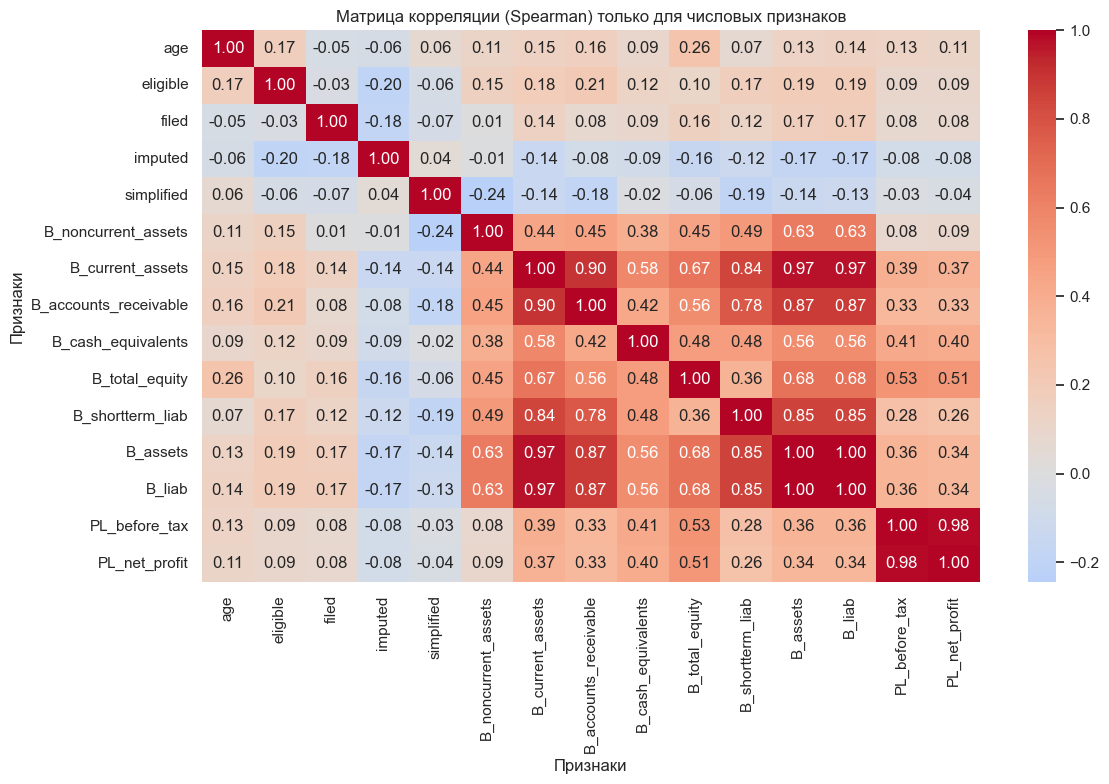

In [21]:
num_for_corr = [
    "age", "eligible", "filed", "imputed", "simplified",
    rename_dict.get("line_1100", "line_1100"),
    rename_dict.get("line_1200", "line_1200"),
    rename_dict.get("line_1230", "line_1230"),
    rename_dict.get("line_1250", "line_1250"),
    rename_dict.get("line_1300", "line_1300"),
    rename_dict.get("line_1500", "line_1500"),
    rename_dict.get("line_1600", "line_1600"),
    rename_dict.get("line_1700", "line_1700"),
    rename_dict.get("line_2300", "line_2300"),
    rename_dict.get("line_2400", "line_2400"),
]

corr_num = df[num_for_corr].corr(method="spearman")

plt.figure(figsize=(12, 8))
sns.heatmap(corr_num, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Матрица корреляции (Spearman) только для числовых признаков")
plt.xlabel("Признаки")
plt.ylabel("Признаки")
plt.tight_layout()
plt.show()


In [22]:
corr_upper = corr_num.where(np.triu(np.ones(corr_num.shape), k=1).astype(bool))

top_pairs = (
    corr_upper.abs()
    .stack()
    .sort_values(ascending=False)
    .head(10)
)

display(top_pairs.to_frame("abs_corr"))

print("\nВывод:")
print("Между финансовыми признаками наблюдаются сильные корреляции.")
print("Например, корреляции, связанные с балансом и финансовыми результатами компаний.")
print("Справочные данные приведены ниже.")


abs_corr
B_assets              B_liab                 0.999419
PL_before_tax         PL_net_profit          0.984388
B_current_assets      B_assets               0.972607
                      B_liab                 0.972126
                      B_accounts_receivable  0.902009
B_accounts_receivable B_assets               0.874311
                      B_liab                 0.873955
B_shortterm_liab      B_assets               0.852973
                      B_liab                 0.852379
B_current_assets      B_shortterm_liab       0.843877


Вывод:
Между финансовыми признаками наблюдаются сильные корреляции.
Например, корреляции, связанные с балансом и финансовыми результатами компаний.
Справочные данные приведены ниже.


### Уже приводились расшифровки кодов отчетности:  

1100 — Итого внеоборотных активов — B_noncurrent_assets  
1200 — Итого оборотных активов — B_current_assets  
1230 — Дебиторская задолженность — B_accounts_receivable  
1250 — Денежные средства и денежные эквиваленты — B_cash_equivalents  
1300 — Итого по разделу «Капитал и резервы» — B_total_equity  
1500 — Итого краткосрочных обязательств — B_shortterm_liab  
1600 — Баланс (сумма актива) — B_assets  
1700 — Баланс (сумма пассива) — B_liab  
2300 — Прибыль (убыток) до налогообложения — PL_before_tax  
2400 — Чистая прибыль (убыток) — PL_net_profit  


# 4. Диаграммы рассеивания  

Построим диаграмы рассеивания scatter plot для двух пар коррелирующих признаков:  

1. итог по активу баланса и итог по пассиву баланса;
2. прибыль до налогообложения и чистая прибыль.

Дополнительно те же пары будут показаны в логарифмической шкале.

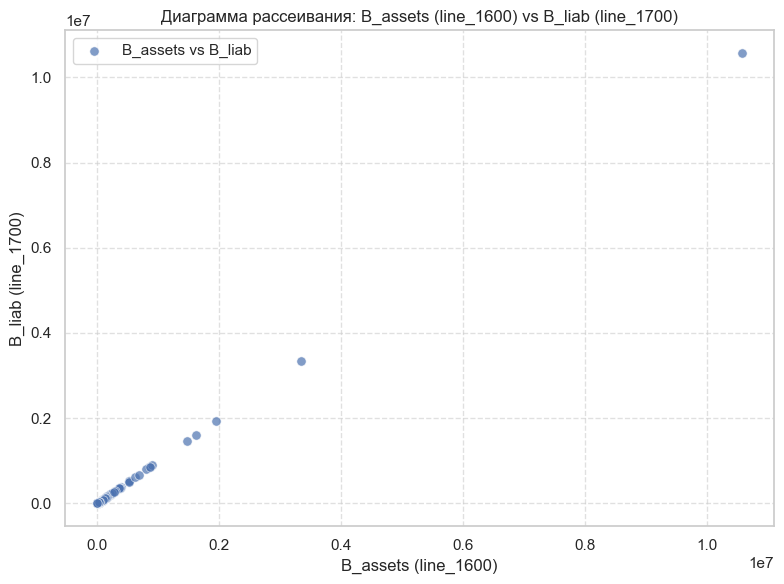


Вывод:
Между итогом по активу и итогом по пассиву баланса отображается приблизительно линейная положительная зависимость.


In [23]:
x_col = rename_dict.get("line_1600", "line_1600")
y_col = rename_dict.get("line_1700", "line_1700")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x=x_col, y=y_col, alpha=0.7, s=45, label=f"{x_col} vs {y_col}")
plt.title(f"Диаграмма рассеивания: {feature_labels[x_col]} vs {feature_labels[y_col]}")
plt.xlabel(feature_labels[x_col])
plt.ylabel(feature_labels[y_col])
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

print("\nВывод:")
print("Между итогом по активу и итогом по пассиву баланса отображается приблизительно линейная положительная зависимость.")


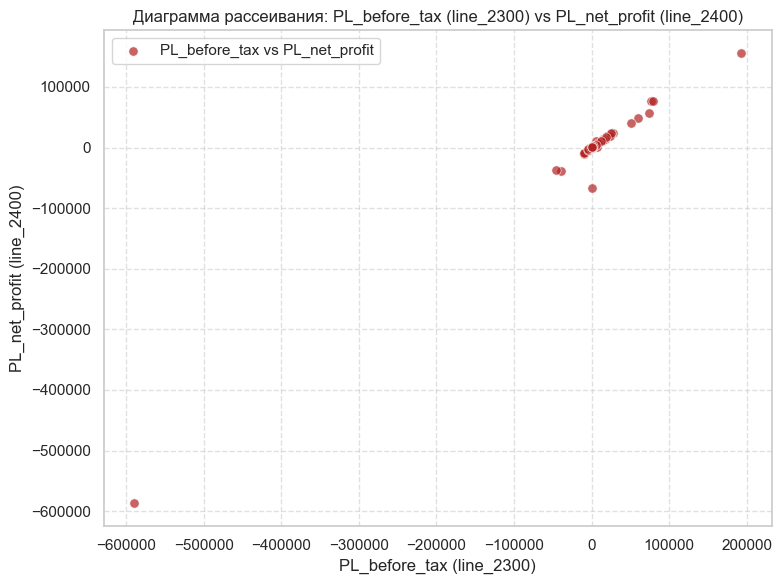


Вывод:
Между прибылью до налогообложения и чистой прибылью также наблюдается линейная положительная связь.
На графике есть отрицательные значения, что соответствует убыточным компаниям.
Также присутствуют выбросы и одиночная аномалия.


In [24]:
x_col = rename_dict.get("line_2300", "line_2300")
y_col = rename_dict.get("line_2400", "line_2400")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x=x_col, y=y_col, alpha=0.7, s=45, label=f"{x_col} vs {y_col}", color="firebrick")
plt.title(f"Диаграмма рассеивания: {feature_labels[x_col]} vs {feature_labels[y_col]}")
plt.xlabel(feature_labels[x_col])
plt.ylabel(feature_labels[y_col])
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

print("\nВывод:")
print("Между прибылью до налогообложения и чистой прибылью также наблюдается линейная положительная связь.")
print("На графике есть отрицательные значения, что соответствует убыточным компаниям.")
print("Также присутствуют выбросы и одиночная аномалия.")


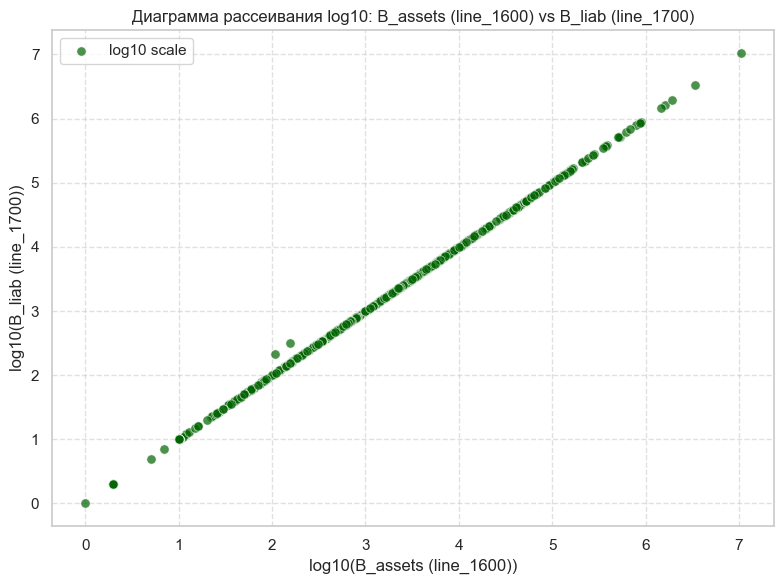

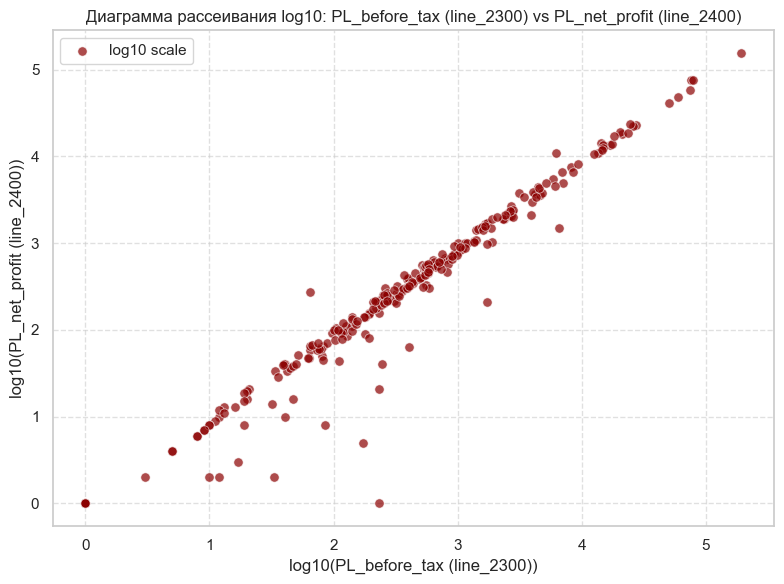

In [25]:
for old_x, old_y, color in [
    ("line_1600", "line_1700", "darkgreen"),
    ("line_2300", "line_2400", "darkred")
]:
    x_col = rename_dict.get(old_x, old_x)
    y_col = rename_dict.get(old_y, old_y)

    tmp = df[[x_col, y_col]].dropna().copy()
    tmp = tmp[(tmp[x_col] > 0) & (tmp[y_col] > 0)]

    if len(tmp) > 0:
        tmp_log = np.log10(tmp)

        plt.figure(figsize=(8, 6))
        sns.scatterplot(data=tmp_log, x=x_col, y=y_col, alpha=0.7, s=45, color=color, label="log10 scale")
        plt.title(f"Диаграмма рассеивания log10: {feature_labels[x_col]} vs {feature_labels[y_col]}")
        plt.xlabel(f"log10({feature_labels[x_col]})")
        plt.ylabel(f"log10({feature_labels[y_col]})")
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.6)
        plt.tight_layout()
        plt.show()


### Вывод для пары B_assets и B_liab:  
В логарифмической шкале линейная зависимость очевидна,  
однако выбросы и небольшой разброс значений сохраняются.  

### Вывод для пары PL_before_tax и PL_net_profit:  
В логарифмической шкале линейная зависимость выражена,  
однако есть выбросы и  сохраняется ощутимый разброс значений.  


# 5. Итоговые выводы

Ниже собраны основные выводы на основе:
- описательной статистики;
- гистограмм;
- корреляционного анализа;
- диаграмм рассеивания.

In [26]:
print("Итоговые выводы, которые верны для данной выборки датасета RFSD:")
print("\n1. В выборке преобладают сравнительно молодые компании:")
print("   медианный возраст составляет 5 лет, средний — около 6.9 года.")
print("\n2. Финансовые признаки содержат много пропусков.")
print("   Пропуски тесно связаны с признаком filed: если отчетность подавали, финансовые показатели присутствуют.")
print("\n3. Итог по активу и итог по пассиву баланса имеют сильную положительную корреляцию.")
print("   Это согласуется с логикой бухгалтерского баланса.")
print("\n4. Прибыль до налогообложения и чистая прибыль также сильно коррелируют.")
print("   Это соответствует взаимосвязи финансовых показателей.")
print("\n5. Финансовые распределения асимметричны и содержат выбросы.")
print("\n6. Корреляции категориальных признаков после числового кодирования интерпретируются условно,")
print("   основные выводы сделаны по числовым финансовым признакам.")


Итоговые выводы, которые верны для данной выборки датасета RFSD:

1. В выборке преобладают сравнительно молодые компании:
   медианный возраст составляет 5 лет, средний — около 6.9 года.

2. Финансовые признаки содержат много пропусков.
   Пропуски тесно связаны с признаком filed: если отчетность подавали, финансовые показатели присутствуют.

3. Итог по активу и итог по пассиву баланса имеют сильную положительную корреляцию.
   Это согласуется с логикой бухгалтерского баланса.

4. Прибыль до налогообложения и чистая прибыль также сильно коррелируют.
   Это соответствует взаимосвязи финансовых показателей.

5. Финансовые распределения асимметричны и содержат выбросы.

6. Корреляции категориальных признаков после числового кодирования интерпретируются условно,
   основные выводы сделаны по числовым финансовым признакам.


# 6. Заключение

В работе был выполнен учебный анализ датасета RFSD: в случайной выборке 20 колонок и 1000 строк.  

Согласно выданному заданию:  
- получена описательная статистика;  
- выявлена высокая доля пропусков в финансовых признаках;  
- показана связь между filed и наличием финансовых данных;
- предпринята попытка поиска закономерностей; 
- обнаружены сильные корреляции между связанными финансовыми признаками;
- построены диаграмы рассеивания;
- визуализированы результаты анализа данных выборки.    
<br>